In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mosapabdelghany/telcom-customer-churn-dataset/Telco_Cusomer_Churn.csv


In [4]:
# Import required library for data handling
import pandas as pd

# Load the dataset (Telco Customer Churn)
# This dataset contains customer details, services used, and churn status
df = pd.read_csv("/kaggle/input/datasets/mosapabdelghany/telcom-customer-churn-dataset/Telco_Cusomer_Churn.csv")

# Display first 5 rows to understand structure of data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# Check exact column names in dataset
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
# Check dataset structure
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


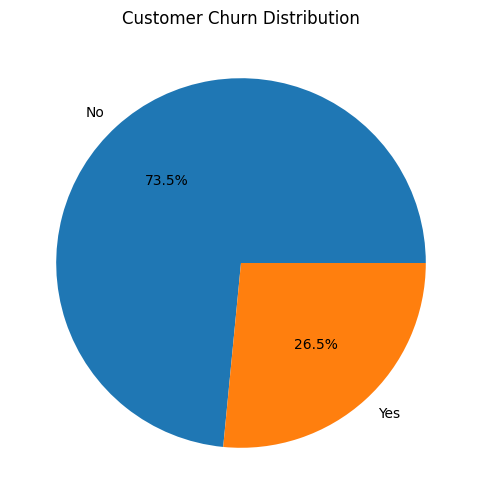

In [9]:
import matplotlib.pyplot as plt

# Count churn vs not churn
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%')
plt.title("Customer Churn Distribution")
plt.show()

In [10]:
# Convert target column into numeric
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Check distribution again
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [11]:
# Remove customer ID (not useful for prediction)
df = df.drop("customerID", axis=1)

# Check if TotalCharges has missing or text values
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values with median
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Show updated dataset
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [14]:
# Target variable (what we predict)
y = df["Churn"]

# Input features (what model learns from)
X = df.drop("Churn", axis=1)

In [13]:
# Convert categorical variables into numeric format
X = pd.get_dummies(X, drop_first=True)

# Check shape after encoding
X.shape

(7043, 30)

In [15]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Check shapes
print(X_train.shape, X_test.shape)

(5634, 19) (1409, 19)


In [18]:
# Import model
from sklearn.ensemble import RandomForestClassifier

# IMPORTANT: Convert categorical variables into numeric BEFORE training
# This ensures model can understand all features
X_encoded = pd.get_dummies(X, drop_first=True)

# Split again after encoding
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42
)

# Create model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
model.fit(X_train, y_train)

print("Model training completed successfully ✔")

Model training completed successfully ✔


In [19]:
from sklearn.metrics import accuracy_score, classification_report

# Predictions on test data
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed performance report
print(classification_report(y_test, y_pred))

Accuracy: 0.7892122072391767
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [20]:
# Probability that each customer will churn
df["Churn Probability"] = model.predict_proba(X_encoded)[:, 1]

df[["Churn Probability"]].head()

,Churn Probability
0,0.31
1,0.03
2,0.73
3,0.00
4,0.78


In [21]:
# Customers most likely to churn
high_risk = df[df["Churn Probability"] > 0.7]

high_risk[["MonthlyCharges", "Contract", "Churn Probability"]].head()

,MonthlyCharges,Contract,Churn Probability
2,53.85,Month-to-month,0.73
4,70.70,Month-to-month,0.78
5,99.65,Month-to-month,1.00
8,104.80,Month-to-month,0.73
13,103.70,Month-to-month,0.83


In [22]:
# Total monthly revenue at risk
revenue_at_risk = high_risk["MonthlyCharges"].sum()

print("Revenue at Risk:", revenue_at_risk)

Revenue at Risk: 103819.2


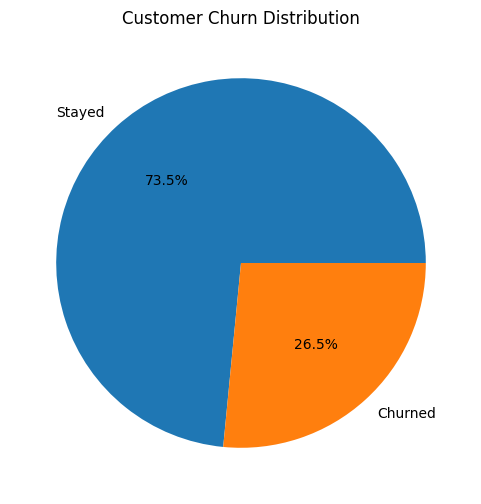

In [25]:
# Import visualization library
import matplotlib.pyplot as plt

# Count how many customers stayed vs churned
churn_counts = df["Churn"].value_counts()

# Create pie chart to show overall churn distribution
plt.figure(figsize=(6,6))

# Labels: 0 = Stayed, 1 = Churned
plt.pie(churn_counts, labels=["Stayed", "Churned"], autopct='%1.1f%%')

# Add title for business understanding
plt.title("Customer Churn Distribution")

# Display chart
plt.show()

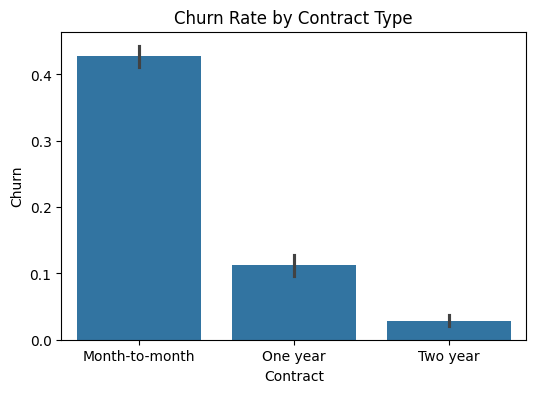

In [26]:
# Import seaborn for advanced visualization
import seaborn as sns

# Set plot size for clarity
plt.figure(figsize=(6,4))

# Show how churn varies by contract type
sns.barplot(x="Contract", y="Churn", data=df)

# Add title to explain insight
plt.title("Churn Rate by Contract Type")

# Display chart
plt.show()

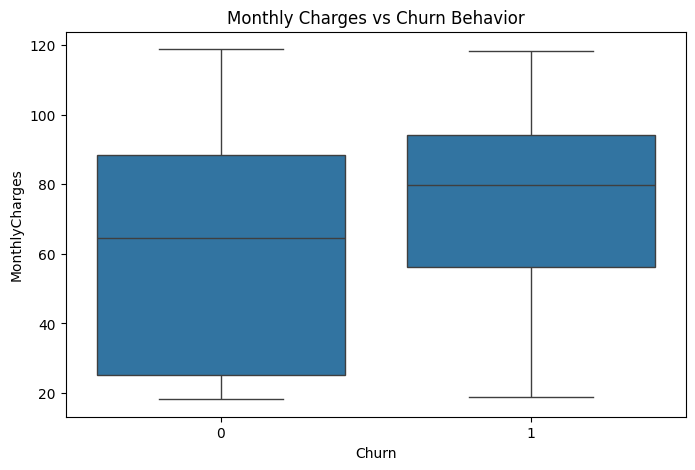

In [27]:
# Set figure size for better visibility
plt.figure(figsize=(8,5))

# Boxplot helps compare distributions between churned and non-churned customers
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

# Title explains business insight
plt.title("Monthly Charges vs Churn Behavior")

# Show chart
plt.show()

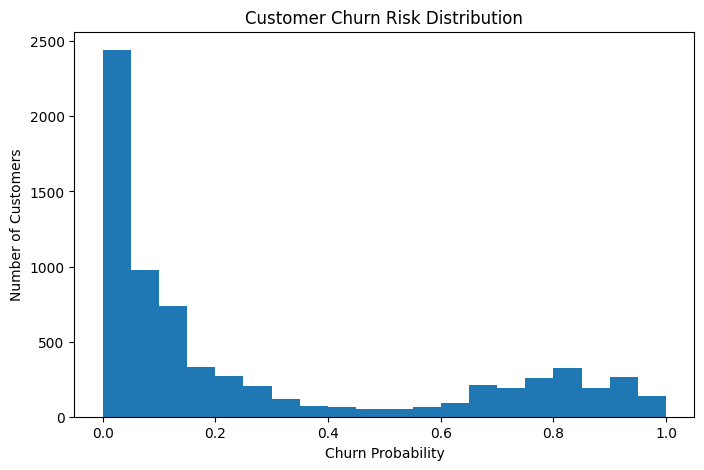

In [28]:
# Generate churn probability from trained model
df["Churn Probability"] = model.predict_proba(X_encoded)[:, 1]

# Set figure size
plt.figure(figsize=(8,5))

# Histogram shows how risk is distributed across customers
plt.hist(df["Churn Probability"], bins=20)

# Add title for interpretation
plt.title("Customer Churn Risk Distribution")

# Label x-axis
plt.xlabel("Churn Probability")

# Label y-axis
plt.ylabel("Number of Customers")

# Show plot
plt.show()

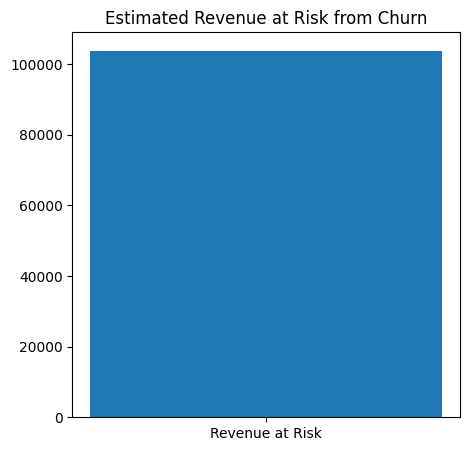

In [29]:
# Calculate total monthly revenue from high-risk customers
revenue_risk = high_risk["MonthlyCharges"].sum()

# Create visualization for financial impact
plt.figure(figsize=(5,5))

# Show revenue at risk as a bar
plt.bar(["Revenue at Risk"], [revenue_risk])

# Add title for business impact
plt.title("Estimated Revenue at Risk from Churn")

# Display chart
plt.show()

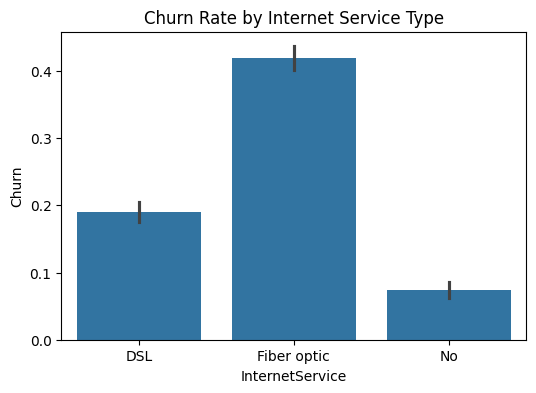

In [30]:
# Set figure size for clarity
plt.figure(figsize=(6,4))

# Show churn rate based on internet service type
sns.barplot(x="InternetService", y="Churn", data=df)

# Title explains business insight clearly
plt.title("Churn Rate by Internet Service Type")

# Display plot
plt.show()

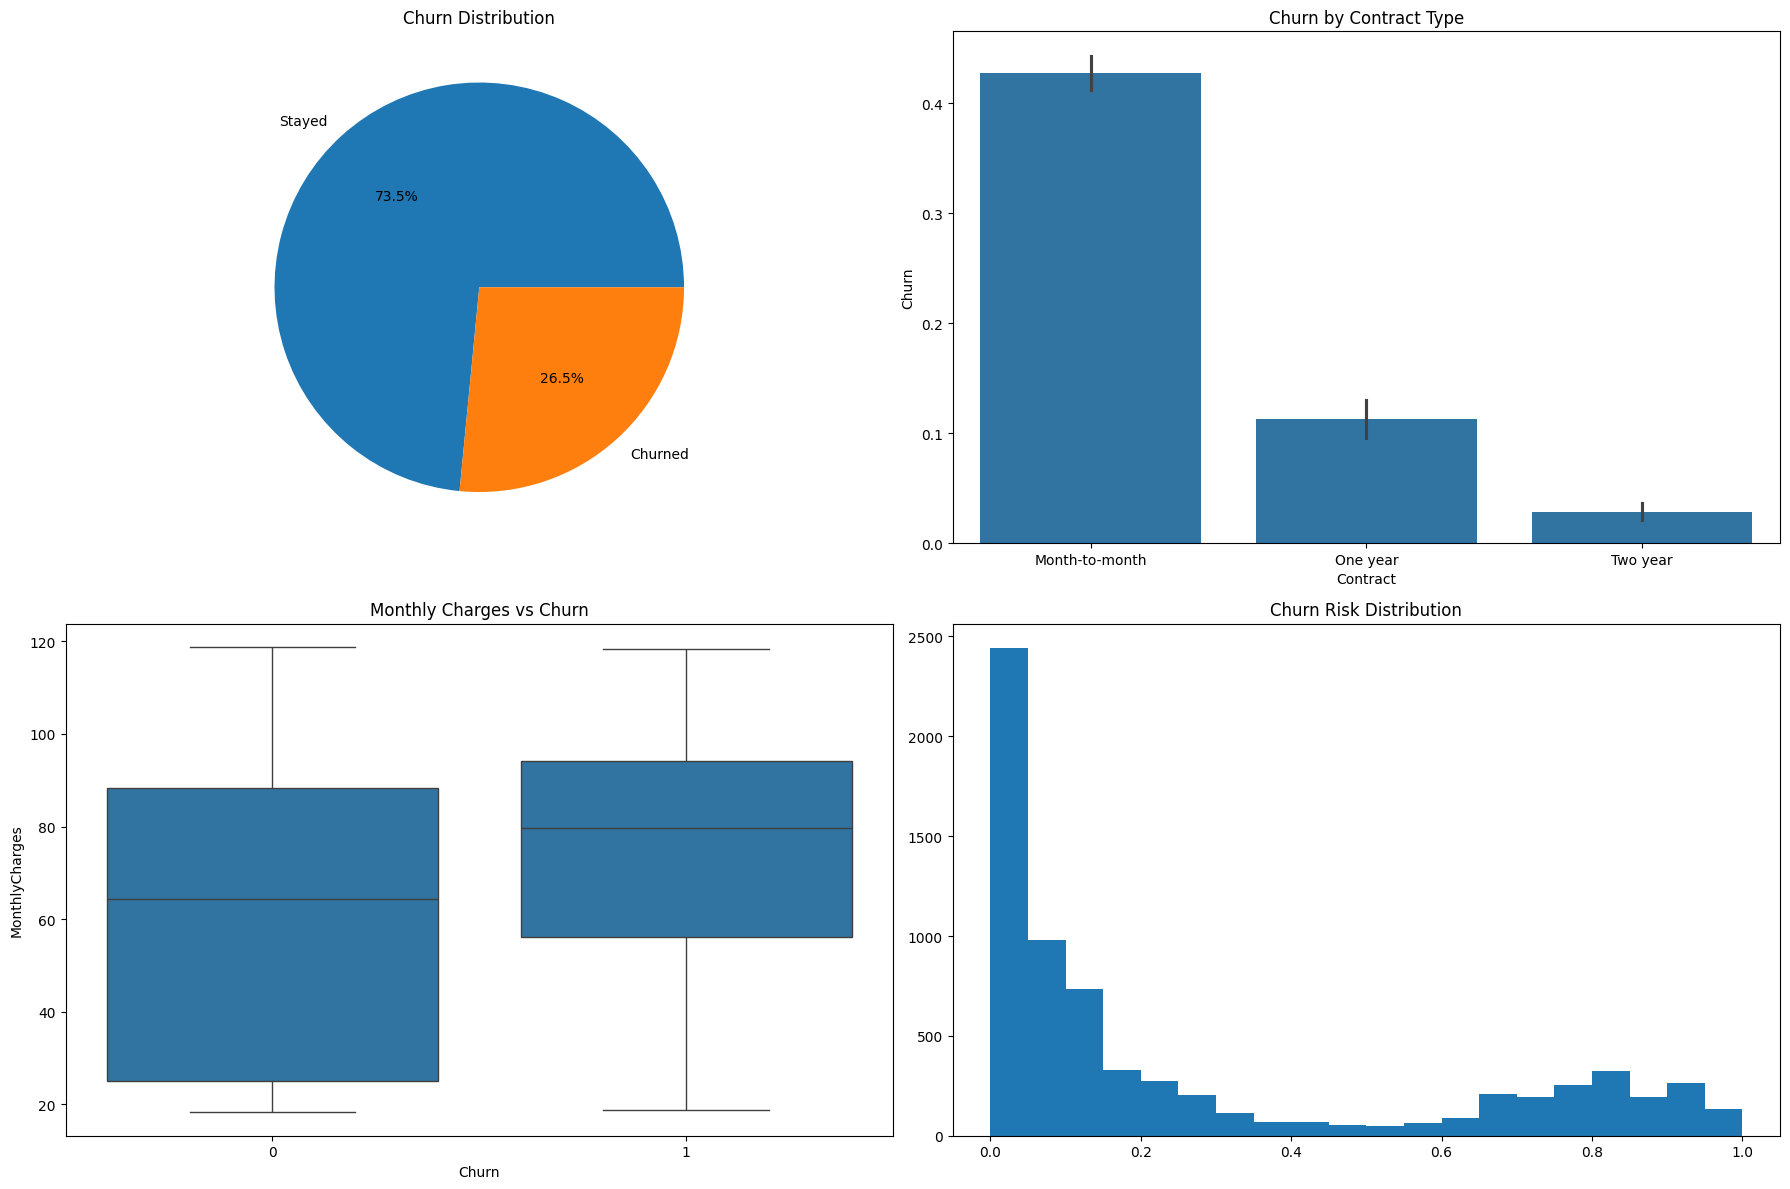

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with multiple subplots (dashboard layout)
plt.figure(figsize=(18,12))

# -------------------------------
# 1. Churn Distribution
# -------------------------------
plt.subplot(2,2,1)
churn_counts = df["Churn"].value_counts()
plt.pie(churn_counts, labels=["Stayed", "Churned"], autopct='%1.1f%%')
plt.title("Churn Distribution")

# -------------------------------
# 2. Contract vs Churn
# -------------------------------
plt.subplot(2,2,2)
sns.barplot(x="Contract", y="Churn", data=df)
plt.title("Churn by Contract Type")

# -------------------------------
# 3. Monthly Charges vs Churn
# -------------------------------
plt.subplot(2,2,3)
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")

# -------------------------------
# 4. Churn Risk Distribution
# -------------------------------
df["Churn Probability"] = model.predict_proba(X_encoded)[:, 1]

plt.subplot(2,2,4)
plt.hist(df["Churn Probability"], bins=20)
plt.title("Churn Risk Distribution")

# Adjust layout
plt.tight_layout()

# Show final dashboard
plt.show()